# Ejercicios prácticos - Módulo 5

In [ ]:
pip install bambi

In [2]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 1. En la siguiente definición de modelo probabilístico cual es el *likelihood*, cual es el *a priori* y cual el *a posteriori*.

$$y_i \sim Normal(\mu, \sigma)$$

$$\mu \sim Normal(0, 10)$$

$$\sigma \sim HalfNormal(25)$$

En este caso tenemos que:

* El likelihood es la distribución $Normal(\mu, \sigma)$ que sigue $y_i$.

* El *a priori* está constituido por las distribuciones $Normal(0, 10)$ y $HalfNormal(25)$ asignadas a $\mu$ y $\sigma$ respectivamente.

* El *a posteriori* es una combinación de los términos anteriores considerando su versión proporcional. Toma la siguiente forma (apróx):
$$p(\mu, \sigma | y) \propto p(y | \mu, \sigma).p(\mu).p(\sigma)$$

### 2. En el modelo del punto 1 ¿cuántos parámetros hay en el posterior? o expresado de otra forma ¿cuántas dimensiones tiene el *a posteriori*?

Podemos ver que hay dos parámetros que describen la distribución *a posteriori*, esos son $\mu$ y $\sigma$, ya que $y$ representa a los datos observados. Expresado de otra forma podemos decir que tenemos **dos dimensiones** en el *a posteriori*.

### 3. En el siguiente modelo ¿cuál es el modelo lineal? ¿cuál el likelihood y cuantos parámetros hay en la distribución *a posteriori*?

$$y \sim Normal(\mu, \epsilon)$$

$$\mu = \alpha + \beta x$$

$$\alpha \sim Normal(0, 10)$$

$$\beta \sim Normal(0, 1)$$

$$\epsilon \sim HalfNormal(25)$$

En este caso tenemos que:

* El modelo lineal viene dado por la expresión: $\mu = \alpha + \beta x$

* El likelihood es la distribución $Normal(\mu, \epsilon)$ que sigue $y$.

* Para entender la cantidad de parámetros que tiene la distribución *a posteriori* podemos pensar en los términos que conforman a la likelihood. Tenemos a $\mu$ y $\epsilon$ que definen media y dispersión de la distribución considerada, como la posterior es una versión "dada vuelta" de esta distribución entonces utilizará los mismos parámetros. Hasta ahora tenemos dos parámetros, pero podemos notar que $\mu$ a su vez está conformada por dos parámetros $\alpha$ y $\beta$ que definen el vínculo lineal con la variable predictora $x$ y eso nos lleva a confirmar que la distribución *a posteriori* cuenta con un total de tres parámetros.

### 4. Usando el conjunto de datos `howell` (disponible en la teórica) realice un modelo lineal del peso ($x$) versus la altura ($y$). Excluya a los menores de 18 años. Exponga los resultados.

Empiezo por cargar los datos a utilizar:

In [ ]:
howell_data = pd.read_csv("data/raw/howell.csv", sep=";")
howell_data_above_18 = howell_data[howell_data.edad >= 18]
howell_data_above_18.head()

,altura,peso,edad,sexo
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


Armo una visualización simple para entender los datos que se van a trabajar:

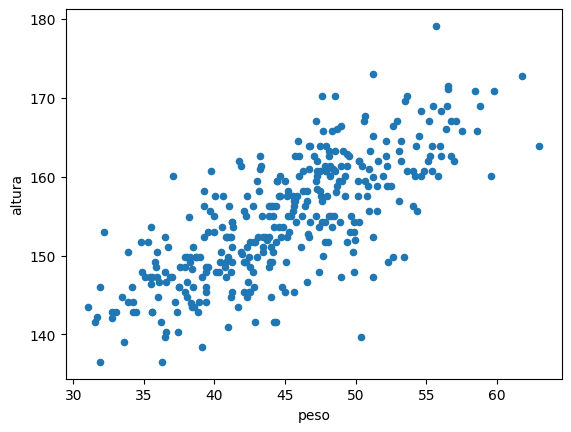

In [ ]:
howell_data_above_18.plot("peso","altura",kind = "scatter")
plt.show()

Podemos ver una notable relación lineal ascendente entre las variables `peso` y `altura`, por lo tanto `peso` resulta un predictor razonable.

Para construir este modelo voy a utilizar a Bambi que tiene una notación más simple para este tipo de modelos. Paso a su definición:

In [ ]:
modelo_howell = bmb.Model('altura ~ peso', howell_data_above_18)
modelo_howell.build()
modelo_howell

       Formula: altura ~ peso
        Family: gaussian
          Link: mu = identity
  Observations: 352
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 154.5971, sigma: 136.2498)
            peso ~ Normal(mu: 0.0, sigma: 2.9978)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 7.7313)

En este caso al tratarse de una regresión lineal simple, Bambi "por detrás" asumió muchas cosas. Voy a desglosarlo en los siguientes puntos:

* Para la variable `altura` asumió una distribución Gaussiana y una función de vínculo identidad ($x=y$), esto es razonable ya que como dije antes estamos tratando una regresión lineal simple.

* Identificó como "objetivo" a $\mu$, variable que representa la media y en donde existe el vínculo lineal.

* Para los priors del intercepto y coeficiente correspondiente a la variable `peso` asumió distribuciones normales con valores débilmente informativos. Algo que me gustaría destacar es la elección que hace sobre los parámetros del prior del intercepto, definió sus valores a partir de lo observado en los datos.

* Luego como "parámetros" auxiliares nos encontramos con $\sigma$ el cual corresponde a la dispersión presente en la distribución normal asumida al principio, tampoco hay nada raro ya que asumió una distribución **HalfTStudent** la cual es razonable para este tipo de variables.

Con todo esto dicho, pasamos a "entrenar" el modelo (lo dije porque la interfaz me recuerda a la de scikit-learn).

In [ ]:
idata_howell = modelo_howell.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, peso]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 172 seconds.


Ya con el sampleo realizado pasamos a hacer uso de otras funcionalidades que ofrece Bambi para poder ver como se desempeña nuestro modelo:

Default computed for conditional variable: peso
Default computed for conditional variable: peso


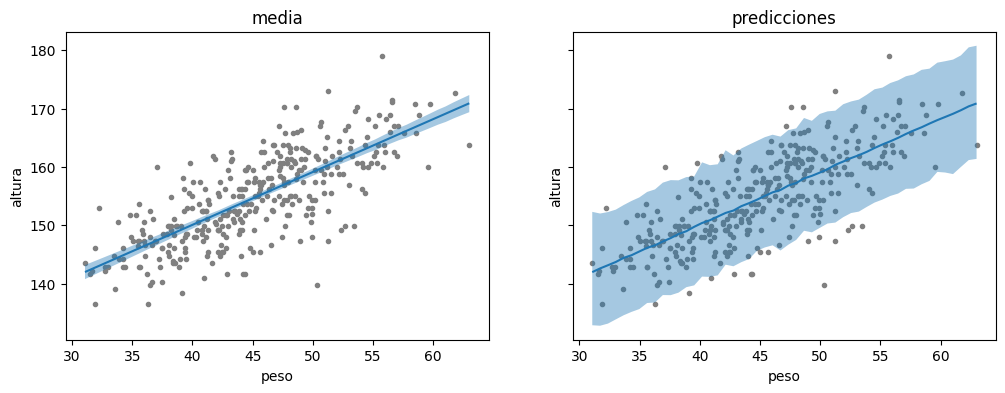

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(modelo_howell, idata_howell, "peso", ax=axes[0])
bmb.interpret.plot_predictions(modelo_howell, idata_howell, "peso", pps=True, ax=axes[1])

axes[0].plot(howell_data_above_18.peso, howell_data_above_18.altura, ".", color="0.5",  zorder=-3)
axes[1].plot(howell_data_above_18.peso, howell_data_above_18.altura, ".", color="0.5", zorder=-3)
axes[0].set_title("media")
axes[1].set_title("predicciones");

Podemos ver que en lineas generales nuestro modelo se desempeña bien, capta la relación creciente en los datos correctamente y cuando realizamos predicciones este abarca casi todo el rango posible de nuestros datos.

Para no olvidar lo que hacíamos antes con PyMC vamos a usar Arviz para estudiar los valores puntuales de los parámetros y sus distribuciones *a posteriori*:

In [ ]:
az.summary(idata_howell)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,5.105,0.195,4.732,5.463,0.003,0.003,5759.0,3038.0,1.0
Intercept,113.868,1.904,110.294,117.358,0.024,0.031,6173.0,2987.0,1.0
peso,0.905,0.042,0.830,0.983,0.001,0.001,6284.0,2938.0,1.0


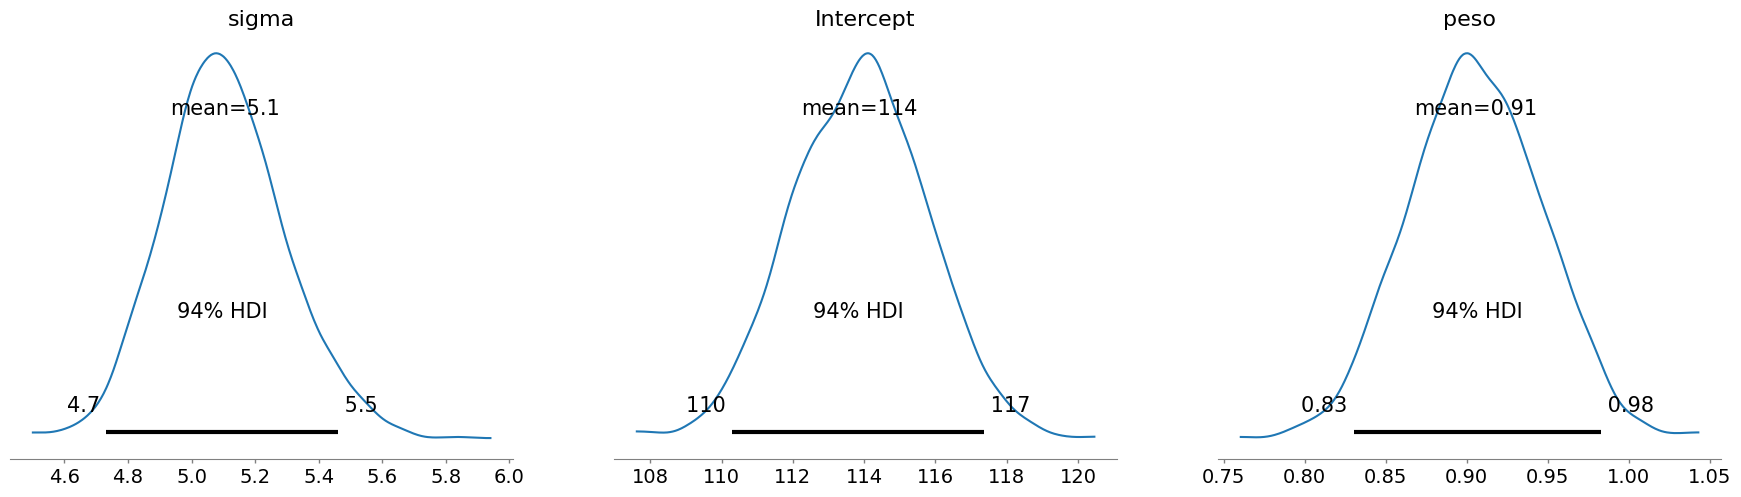

In [ ]:
az.plot_posterior(idata_howell)
plt.show()

Podemos ver que obtuvimos valores razonables para cada parámetro y no hubieron problemas durante la estimación. Nada más que agregar.

### 5. Para 4 individuos se registraron los pesos (45.73, 65.8, 54.2, 32.59), pero no las alturas. Usando el modelo del punto anterior prediga la altura esperada para cada individuo junto con un intervalo de credibilidad del 50% y del 89%.

En este caso Bambi permite hacer predicciones sobre datos no observados a un estilo scikit-learn, para eso vamos a utilizar el método `predict`:

In [ ]:
nuevos_individuos = [45.73, 65.8, 54.2, 32.59]
modelo_howell.predict(idata_howell, kind = 'pps',data=pd.DataFrame({'peso':nuevos_individuos}))

Y ahora vemos los gráficos de las predicciones con intervalos de credibilidad del 50% y 89%:

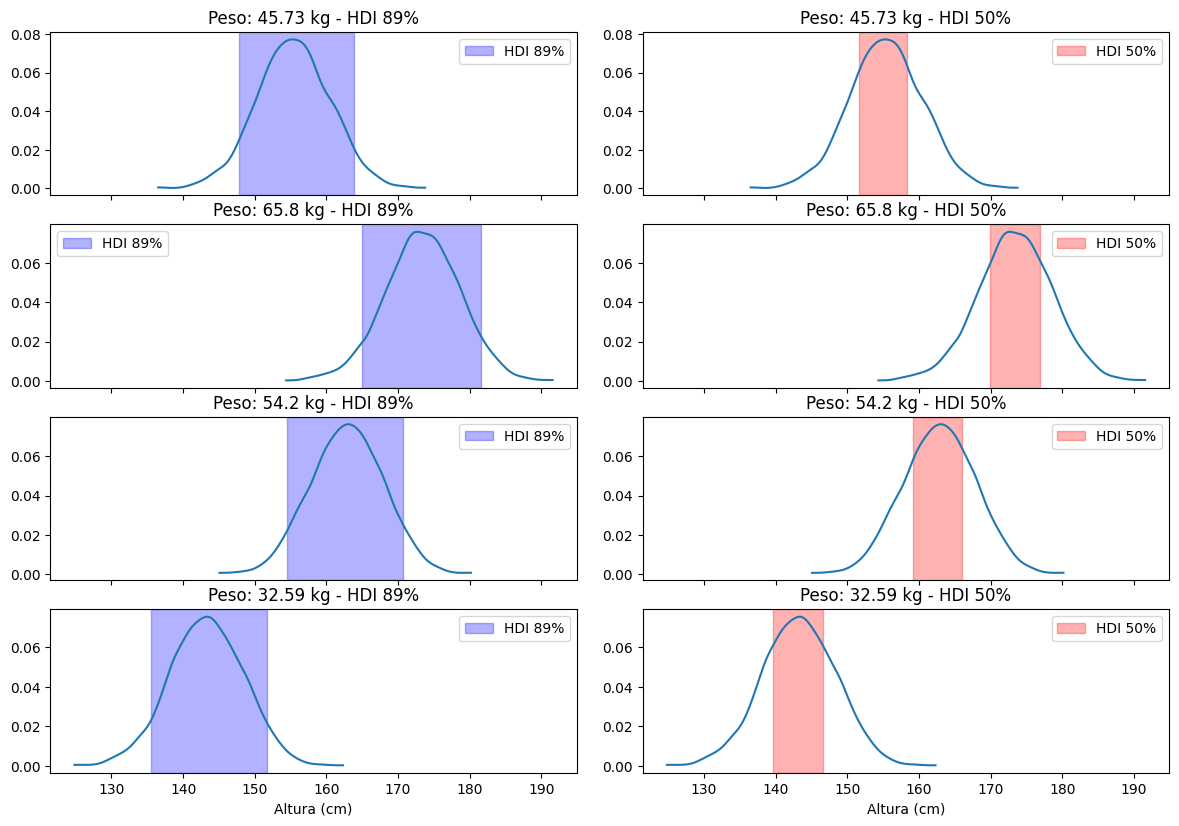

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 8), sharex=True)
plt.tight_layout()

for i in range(4):
    y_ppc = idata_howell.posterior_predictive["altura"].stack(sample=("chain", "draw"))[i]
    grid, pdf = az.stats.density_utils._kde_linear(y_ppc.values)

    # Calcular HDI 89% y 50%
    hdi_89 = az.hdi(y_ppc.values, hdi_prob=0.89)
    hdi_50 = az.hdi(y_ppc.values, hdi_prob=0.50)

    # Primera columna: HDI 89%
    axes[i, 0].plot(grid, pdf)
    axes[i, 0].axvspan(hdi_89[0], hdi_89[1], alpha=0.3, color='blue', label='HDI 89%')
    axes[i, 0].set_title(f'Peso: {nuevos_individuos[i]} kg - HDI 89%')
    axes[i, 0].legend()

    # Segunda columna: HDI 50%
    axes[i, 1].plot(grid, pdf)
    axes[i, 1].axvspan(hdi_50[0], hdi_50[1], alpha=0.3, color='red', label='HDI 50%')
    axes[i, 1].set_title(f'Peso: {nuevos_individuos[i]} kg - HDI 50%')
    axes[i, 1].legend()

# Etiquetas para los ejes
for i in range(4):
    if i == 3:
        axes[i, 0].set_xlabel('Altura (cm)')
        axes[i, 1].set_xlabel('Altura (cm)')

plt.show()

Podemos ver que obtenemos una distribución para cada predicción que realizamos, además las mismas son razonables: a un mayor peso una mayor altura esperada, tal y como se mostraba en la relación de los datos que observamos anteriormente.

### 6. Repita el punto 4 pero para los menores de 18 años. Exponga los resultados.

Bueno aquí podemos permitirnos ir más al grano, empiezo por filtrar los datos:

In [ ]:
howell_data_under_18 = howell_data[howell_data.edad <= 18]
howell_data_under_18.head()

,altura,peso,edad,sexo
18,121.92,19.617854,12.0,1
19,105.41,13.947954,8.0,0
20,86.36,10.489315,6.5,0
23,129.54,23.586784,13.0,1
24,109.22,15.989118,7.0,0


Hago el gráfico para observar la relación:

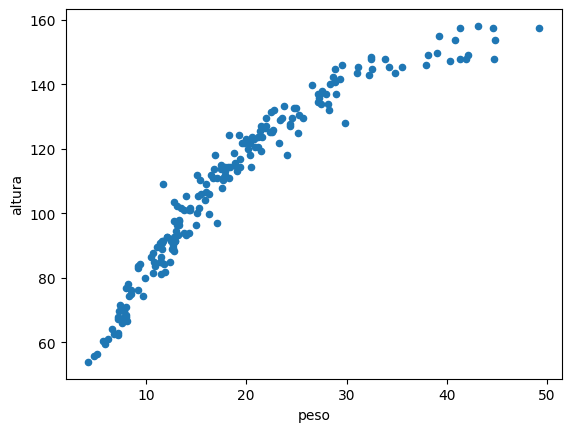

In [ ]:
howell_data_under_18.plot("peso","altura",kind = "scatter")
plt.show()

Aquí vemos la misma relación creciente pero esta vez hay como una cierta "curva" entre los datos, mirandolo de primeras pensaría que es una función raíz cuadrada con una fuerte pendiente.

Uso Bambi de vuelta para construir el modelo:

In [ ]:
modelo_howell_under_18 = bmb.Model('altura ~ peso', howell_data_under_18)
modelo_howell_under_18.build()
modelo_howell_under_18

       Formula: altura ~ peso
        Family: gaussian
          Link: mu = identity
  Observations: 198
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 109.6386, sigma: 145.7383)
            peso ~ Normal(mu: 0.0, sigma: 6.7961)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 26.3791)

Es bastante similar a lo que obtuvimos en el primer modelo, lo que cambia son algunos valores específicos. Paso directamnete a la parte de sampleo:

In [ ]:
idata_howell_under_18 = modelo_howell_under_18.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, peso]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 100 seconds.


Vemos el desempeño del modelo con respecto a los datos:

Default computed for conditional variable: peso
Default computed for conditional variable: peso


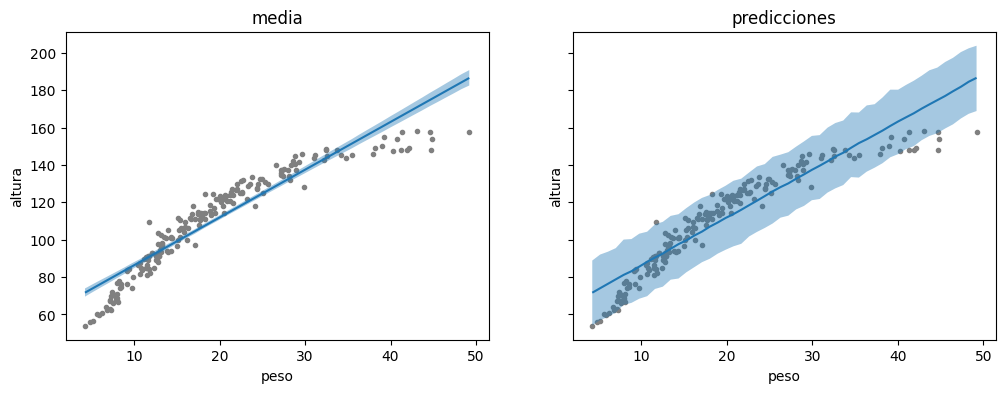

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(modelo_howell_under_18, idata_howell_under_18, "peso", ax=axes[0])
bmb.interpret.plot_predictions(modelo_howell_under_18, idata_howell_under_18, "peso", pps=True, ax=axes[1])

axes[0].plot(howell_data_under_18.peso, howell_data_under_18.altura, ".", color="0.5",  zorder=-3)
axes[1].plot(howell_data_under_18.peso, howell_data_under_18.altura, ".", color="0.5", zorder=-3)
axes[0].set_title("media")
axes[1].set_title("predicciones");

Aquí vemos ese **mal ajuste** que hace el modelo, esto tiene que ver con lo que habíamos observado antes en el gráfico que relaciona a los datos. Una evolución natural que se me ocurre es armar un polinomio en torno a la variable `peso` que involucre un término elevado a potencia $1/2$.

### 7. Use el modelo `modelo_bl` pero aplicada al conjunto de datos iris. Intente clasificar setosa o versicolor en función de `sepal_length`. ¿Cuán útil es este modelo comparado con una regresión logística?

Para recordar, tenemos que `modelo_bl` es un modelo de regresión lineal simple implementado en PyMC, basado originalmente en datos de bicicletas. Al ser una regresión lineal simple asumimos que la variable objetivo (especies en este caso) sigue una distribución normal. Ahora voy a cargar los datos y copiar la misma estructura que está presente en el módulo correspondiente:

In [ ]:
iris = pd.read_csv("data/raw/iris.csv")

De vuelta, para recordar. Tenemos dos clases, **setosa y versicolor**, y solo una variable independiente, **la longitud del sépalo**. Como se hace normalmente, vamos a codificar las variables categóricas setosa y versicolor con los números 0 y 1 usando pandas:

In [ ]:
df = iris.query("species == ('setosa', 'versicolor')")
y_0 = pd.Categorical(df['species']).codes
x_n = 'sepal_length'
x_0 = df[x_n].values
x_c = x_0 - x_0.mean()

Ahora sí construimos a `modelo_bl` añadiendo como nuevo parámetro a estimar a `bd` el cuál es el limite de decisión, de resto todo sigue igual al código original:

In [ ]:
with pm.Model() as modelo_bl:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=5)
    σ = pm.HalfCauchy('σ', 10)
    μ = pm.Deterministic('μ', α + β * x_c)
    bd = pm.Deterministic('bd', (0.5)-α/β)
    _ = pm.Normal('y_pred', mu=μ, sigma=σ, observed=y_0)

    idata_bl = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 80 seconds.


Con el muestreo listo y luego de ver que no hayan problemas durante el mismo, pasamos a generar un gráfico similar al observado en el módulo cuando se construyó el modelo basado en Iris pero con regresión logística. Este nos permitirá ver claramente las falencias de nuestro modelo:

(-0.1, 1.1)

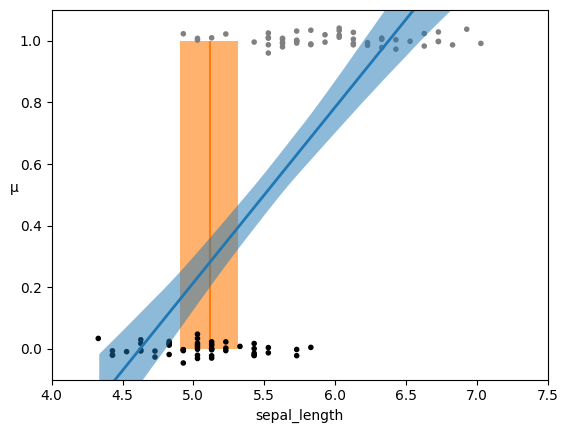

In [ ]:
posterior = idata_bl.posterior
theta = posterior["μ"].mean(("chain", "draw"))
idx = np.argsort(x_c)

_, ax = plt.subplots()

ax.plot(x_c[idx], theta[idx], color='C0', lw=2)
ax.vlines(posterior['bd'].mean(("chain", "draw")), 0, 1, color='C1', zorder=0)
bd_hdi = az.hdi(posterior['bd'])
ax.fill_betweenx([0, 1], bd_hdi["bd"][0], bd_hdi["bd"][1], color='C1', alpha=0.6, lw=0)
ax.scatter(x_c, np.random.normal(y_0, 0.02), marker='.', color=[f'{0.5*x}' for x in y_0])
az.plot_hdi(x_c, posterior['μ'], color='C0', ax=ax, fill_kwargs={"lw": 0})
ax.set_xlabel(x_n)
ax.set_ylabel('μ', rotation=0)
# usar escala original para los xticks
locs, _ = plt.xticks()
ax.set_xticks(locs, np.round(locs + x_0.mean(), 1));
ax.set_ylim(-0.1,1.1)

Aquí vemos claramente que al no utilizar la función de vínculo sigmoidea el modelo ajustó una recta (por el vínculo lineal) **y las clasificaciones son simplemente horribles**. Para responder a la pregunta del enunciado se puede decir que este modelo no es nada útil al compararlo con una regresión logística ya que habrán muchos puntos erróneamente clasificados si nos badamos en el umbral de decisión `bd`.

### 8. Vuelva a correr el `modelo_rl` pero esta vez usando la variable petal_width ¿En que difieren los resultados? ¿Cuán ancho o angosto es el intervalo HDI 94%?

Tenemos que `modelo_rl` fue el modelo de regresión logística definido en el módulo para clasificar a dos especies pertenecientes al conjunto de datos de iris: "setosa" y "versicolor". Para ese caso se utilizó PyMC y como variable predictora se usó a `sepal_length`, ahora la idea es mantener la misma estructura pero cambiar la variable predictora por `petal_width`.

Procedo a copiar el código presente en el módulo haciendo los cambios correspondientes:

In [ ]:
df = iris.query("species == ('setosa', 'versicolor')")
y_0 = pd.Categorical(df['species']).codes
x_n = 'petal_width'
x_0 = df[x_n].values
x_c = x_0 - x_0.mean()

Construyo el modelo y realizo el muestreo:

In [ ]:
with pm.Model() as modelo_rl:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=5)

    μ = α + β * x_c
    θ = pm.Deterministic('θ', pm.math.sigmoid(μ))
    bd = pm.Deterministic('bd', -α/β)

    yl = pm.Bernoulli('yl', p=θ, observed=y_0)
    idata_rl = pm.sample(random_seed=123)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 142 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.


Bueno antes que nada pudimos ver que durante el muestreo se presentaron divergencias así que se puede pensar a eso como una diferencia respecto del modelo original que utilizaba a `sepal_length`. Voy a realizar un gráfico similar al presente en el módulo para ver en acción al modelo junto con los datos:

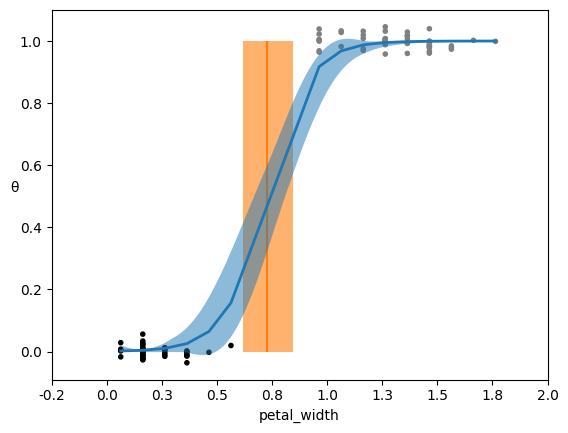

In [ ]:
posterior = idata_rl.posterior
theta = posterior["θ"].mean(("chain", "draw"))
idx = np.argsort(x_c)

_, ax = plt.subplots()

ax.plot(x_c[idx], theta[idx], color='C0', lw=2)
ax.vlines(posterior['bd'].mean(("chain", "draw")), 0, 1, color='C1', zorder=0)
bd_hdi = az.hdi(posterior['bd'])
ax.fill_betweenx([0, 1], bd_hdi["bd"][0], bd_hdi["bd"][1], color='C1', alpha=0.6, lw=0)
ax.scatter(x_c, np.random.normal(y_0, 0.02), marker='.', color=[f'{0.5*x}' for x in y_0])
az.plot_hdi(x_c, posterior['θ'], color='C0', ax=ax, fill_kwargs={"lw": 0})
ax.set_xlabel(x_n)
ax.set_ylabel('θ', rotation=0)
# usar escala original para los xticks
locs, _ = plt.xticks()
ax.set_xticks(locs, np.round(locs + x_0.mean(), 1));

Aquí el umbral de decisión `bd` cambia ya que está en términos de `petal_width`, además parece ser un **mejor modelo** ya que no vemos puntos negros por delante ni por detrás de la linea naranja, es decir que nuestro modelo logra diferenciar correctamente a las clases.

Ahora para terminar y responder la pregunta que hace el enunciado tenemos que si comparamos la longitud del intervalo HDI 94% de este modelo con respecto al original notaremos **que este es más angosto**, se nota esto más fuerte cuando el modelo está alrededor de los puntos. En el modelo original se presentaba una mayor longitud del intervalo incluso estando sobre los datos, cosa que aquí no ocurre.

### 9. Lea este [post](https://twiecki.io/blog/2017/02/08/bayesian-hierchical-non-centered/) y replique los resultados usted mismo.

El post empieza hablando sobre los modelos jerárquicos y como estos no son apreciados lo suficiente, el autor argumenta que las jerarquías existen en muchos conjuntos de datos y modelarlas apropiadamente agrega mucho poder estadístico al análisis que se está llevando a cabo.

Luego de esa introducción el autor dice que quiere enfocarse en un problema común al tratar de sacar estimaciones a partir de un modelo jerárquico y que para eso va a reconstruir un modelo de regresión lineal jerárquica basado en los datos de radon. La referencia que encontré con respecto a PyMC y dichos datos es [esta](https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/multilevel_modeling.html#example-radon-contamination-gelman2006data).

In [ ]:
sns.set_style('whitegrid')
np.random.seed(123)
data = pd.read_csv("data/raw/radon.csv")
county_names = data.county.unique()
county_idx = data.county_code.values

n_counties = len(data.county.unique())

#### La aparición del problema

El autor indica que normalmente al construir modelos jerárquicos estos se especifican de una forma **centrada**. En el caso de la regresión las pendientes individuales estarán centradas en una media común del grupo en cuestión junto con una varianza del mismo grupo, que es lo que controla la regularización.

Voy a generar el modelo tal cual está en el post:

In [6]:
with pm.Model() as hierarchical_model_centered:
    # Hyperpriors for group nodes
    mu_a = pm.Normal('mu_a', mu=0., sigma=100**2)
    sigma_a = pm.HalfCauchy('sigma_a', 5)
    mu_b = pm.Normal('mu_b', mu=0., sigma=100**2)
    sigma_b = pm.HalfCauchy('sigma_b', 5)

    # Intercept for each county, distributed around group mean mu_a
    # Above we just set mu and sd to a fixed value while here we
    # plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal('a', mu=mu_a, sigma=sigma_a, shape=n_counties)

    # Intercept for each county, distributed around group mean mu_a
    b = pm.Normal('b', mu=mu_b, sigma=sigma_b, shape=n_counties)

    # Model error
    eps = pm.HalfCauchy('eps', 5)

    # Linear regression
    radon_est = a[county_idx] + b[county_idx] * data.floor.values

    # Data likelihood
    radon_like = pm.Normal('radon_like', mu=radon_est, sigma=eps, observed=data.log_radon)

Empiezo el muestreo:

In [ ]:
with hierarchical_model_centered:
    hierarchical_centered_trace = pm.sample()

Output()

ERROR:pymc.stats.convergence:There were 466 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


En este caso obtuve **466 divergencias**, podemos ver que este modelo tiene problemas. Veamos ahora que ocurrió con las cadenas durante el muestreo:

<Figure size 800x500 with 0 Axes>

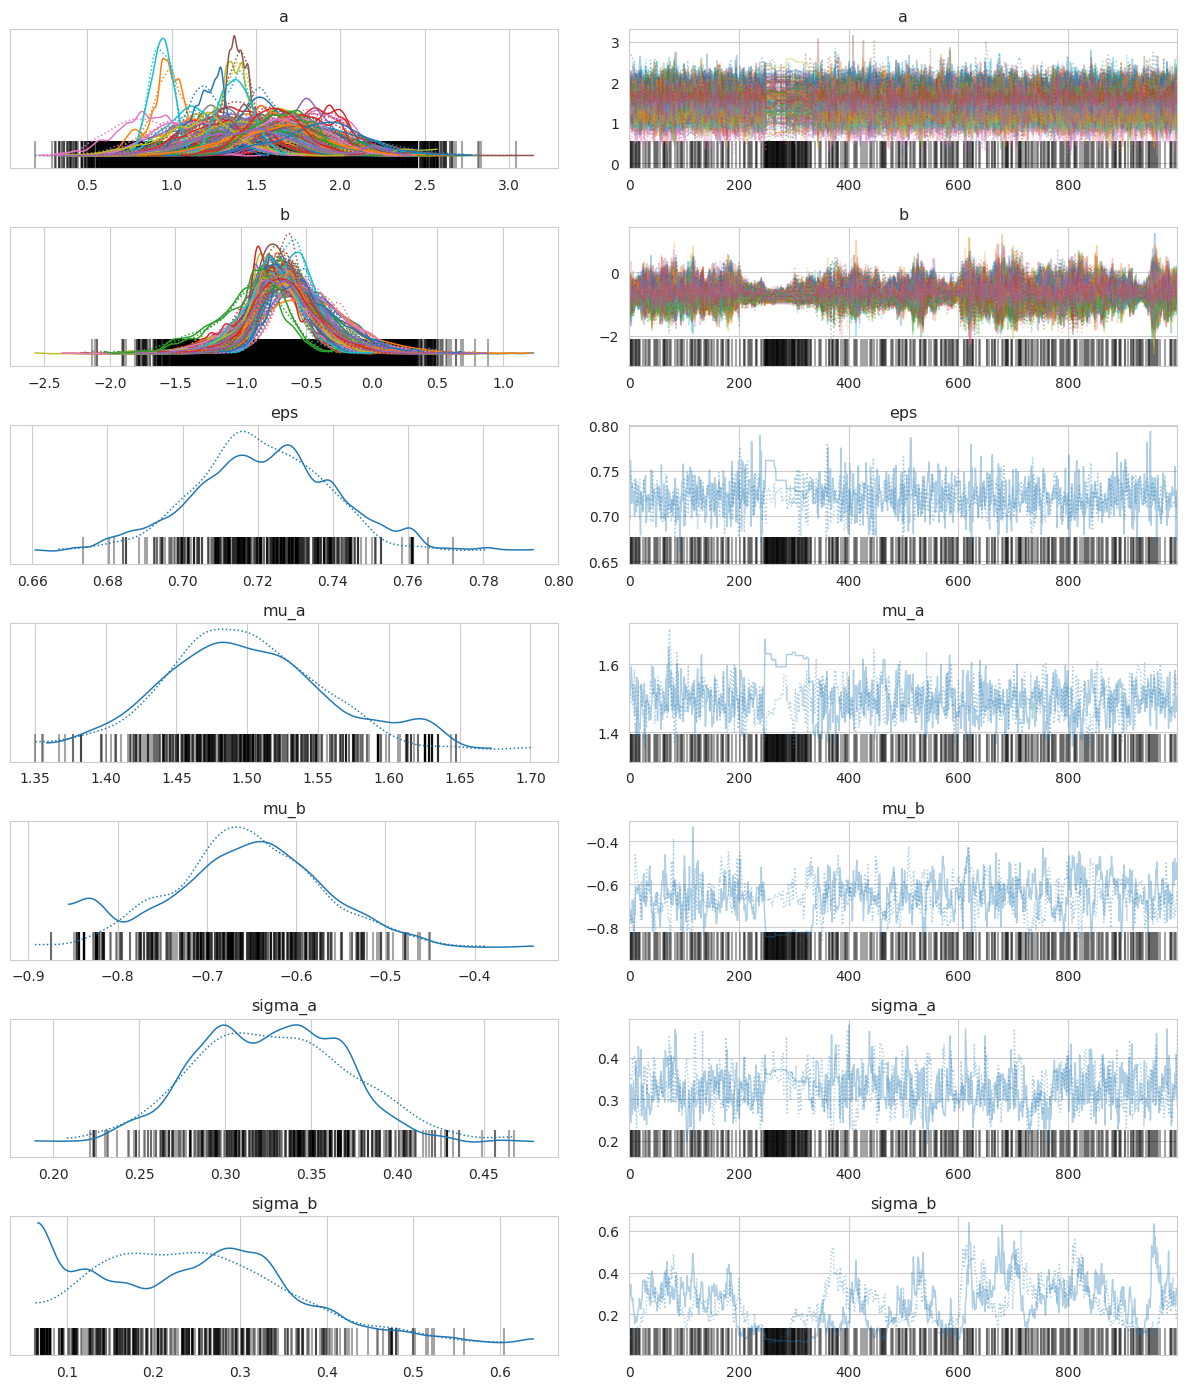

In [ ]:
plt.figure(figsize=(8, 5))
pm.plot_trace(hierarchical_centered_trace)
plt.tight_layout()
plt.show()

Todas tienen problemas, pero en este caso el autor hace un foco especial en `sigma_b` y procede a mirar su `r_hat`:

In [ ]:
az.summary(hierarchical_centered_trace, var_names = ['sigma_b'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_b,0.246,0.109,0.065,0.425,0.02,0.006,28.0,39.0,1.08


En su caso da por debajo de 1.01, en mi caso dió 1.08 así que aquí se ve más claramente la existencia de problemas. Hay que recordar que este diagnóstico lo que hace es comparar la varianza entre cadenas con la varianza dentro de cada cadena.

Aquí el autor procede a generar gráficos para entender que es lo que está ocurriendo, más concretamente genera un gráfico de las pendientes `b` y su varianza por grupo `sigma_b`. Se grafica una única cadena:

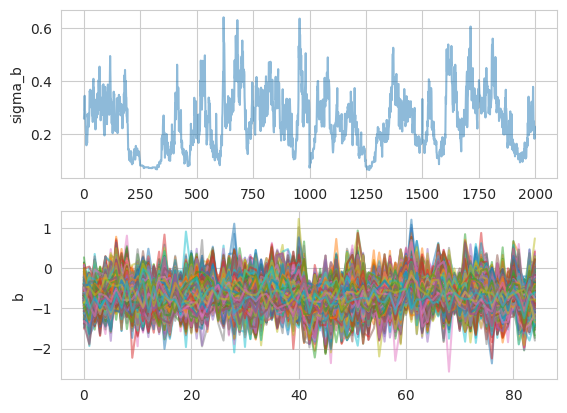

In [ ]:
fig, axs = plt.subplots(nrows=2)
axs[0].plot(hierarchical_centered_trace.posterior['sigma_b'].stack(samples=("chain", "draw")), alpha=.5)
axs[0].set(ylabel='sigma_b')
axs[1].plot(hierarchical_centered_trace.posterior['b'].stack(samples=("chain", "draw")), alpha=.5)
axs[1].set(ylabel='b')
plt.show()

Aquí se nota más claramente lo que ocurre y el autor lo resalta: `sigma_b` explora valores muy bajos y se tiende a quedar atascado ahí por un rato. Según el autor esto es un patrón común cuando el método de muestreo nos intenta decir que hay una región en el espacio que no puede llegar a explorar eficientemente.

Lo más importante que menciona el autor (considero yo) es que cuando `sigma_b` está explorando estos valores bajos, las pendientes de cada grupo `b_i` se comprimen todas juntas. Es lo que el autor llama el "embudo del infierno" (realmente solo se llama "embudo" pero se añade la parte de infierno para darle un tono más dramático).

#### El embudo del infierno (y como escapar de él)

Para notar este efecto de embudo el autor selecciona una pendiente aleatoria `b` (la 75 en este caso) y genera un gráfico de la distribución *a posteriori* conjunta considerando también a `sigma_b`.

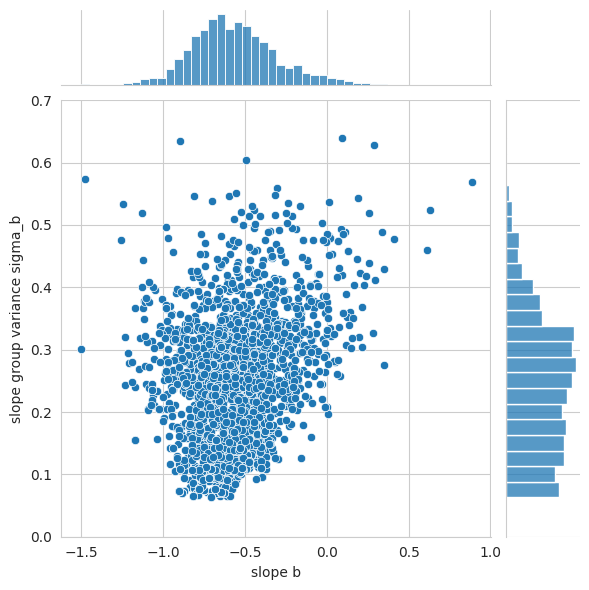

In [ ]:
x = pd.Series(hierarchical_centered_trace.posterior['b'].stack(samples=("chain", "draw"))[74], name='slope b')
y = pd.Series(hierarchical_centered_trace.posterior['sigma_b'].stack(samples=("chain", "draw")), name='slope group variance sigma_b')

sns.jointplot(x=x, y=y, ylim=(0, .7))

De este gráfico no hay nada raro, según disminuye la varianza grupal `sigma_b` las pendientes individuales `b` no tienen permitido desviarse demasiado de la media grupal de la pendiente, llevando así a que **todas se colapsen en torno a dicha media**.

El autor remarca que esta propiedad de la distribución *a posteriori* no es problemática en si misma, pero hace que el trabajo de muestreo se vuelva realmente complicado. Aquí viene la parte intuitiva y lo que me hizo a mi personalmente entender el problema:

*Imagina un [Metropolis-Hastings](https://twiecki.io/blog/2015/11/10/mcmc-sampling/) explorando este espacio con un `step_size`  mediano (PyMC utiliza NUTS pero la intuición es la misma): en la región más amplia podemos realizar saltos cómodamente y explorar la distribución a posteriori. Sin embargo, según nos movemos a la zona más angosta de la distribución únicamente podemos cambiar a `b` y `sigma_b` solamente en tamaños pequeños (no podemos saltar tan fuerte). Esto hace que el proceso de muestreo se quede atascado en dicha región y por ende todas las proposiciones para cambiar de posición serán rechazadas ya que los pasos que tenemos predefinidos son muy grandes para esta región de la distribución, haciendo la exploración muy ineficiente.*

La pregunta natural que surge aquí, y el autor la menciona, es si existe un método que permita variar el `step_size` según la densidad de la región que nos encontramos explorando. El autor dice que si existe y es conocido como el  [Riemannian HMC](https://arxiv.org/abs/0907.1100), pero que este método a pesar de funcionar bien es bastante costoso para generar muestras.

#### Reparametrización

Entonces si no podemos ajustar el `step_size` a la región que se encuentra explorando, **¿podríamos ajustar la región para hacer más fácil el proceso de muestreo?**. Esto es posible y bastante simple gracias a un pequeño truco de **reparametrización**, se llama **la versión no centrada**.

Procedo a volver a crear la estructura del modelo pero ahora con este truco incorporado:

In [14]:
with pm.Model() as hierarchical_model_non_centered:
    # Hyperpriors for group nodes
    mu_a = pm.Normal('mu_a', mu=0., sigma=100**2)
    sigma_a = pm.HalfCauchy('sigma_a', 5)
    mu_b = pm.Normal('mu_b', mu=0., sigma=100**2)
    sigma_b = pm.HalfCauchy('sigma_b', 5)

    # Before:
    # a = pm.Normal('a', mu=mu_a, sd=sigma_a, shape=n_counties)
    # Transformed:
    a_offset = pm.Normal('a_offset', mu=0, sigma=1, shape=n_counties)
    a = pm.Deterministic("a", mu_a + a_offset * sigma_a)

    # Before:
    # b = pm.Normal('b', mu=mu_b, sd=sigma_b, shape=n_counties)
    # Now:
    b_offset = pm.Normal('b_offset', mu=0, sigma=1, shape=n_counties)
    b = pm.Deterministic("b", mu_b + b_offset * sigma_b)

    # Model error
    eps = pm.HalfCauchy('eps', 5)

    radon_est = a[county_idx] + b[county_idx] * data.floor.values

    # Data likelihood
    radon_like = pm.Normal('radon_like', mu=radon_est, sigma=eps, observed=data.log_radon)

En esta parte el autor quiere que prestemos atención a las definiciones de  `a_offset`, `a`, `b_offset` y `b` para compararlas con lo que teníamos antes. Aquí es donde surge la clásica pregunta: ¿que está pasando?.

Pues el autor dice que lo que ocurre que con esta versión del modelo es que en vez de decir que las pendientes individuales `b` están normalmente distribuidas alrededor de una media grupal ahora pasamos a decir que están desplazadas de la media grupal según un cierto valor. Tenemos que definir que tan lejos de la media queremos que los valores se desvíen (cuanta regularización aplicar). Aquí es cuando entra  `sigma_b` pues multiplicamos el desplazamiento `(a_b)_offset` por la desviación para así obtener el mismo efecto que teníamos en el modelo original.

El autor remarca algo importante al final: **en esta versión `b_offset` y `sigma_b` son mayormente independientes**.

Ahora si, muestramos de vuelta:

In [16]:
with hierarchical_model_non_centered:
    hierarchical_non_centered_trace = pm.sample()

Output()

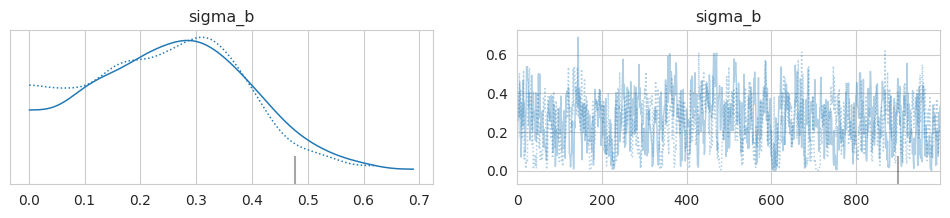

In [ ]:
pm.plot_trace(hierarchical_non_centered_trace, var_names=['sigma_b']);

Vemos que se ve **mucho mejor que antes**. Veamos de vuelta el gráfico de la distribución *a posteriori* conjunta entre `sigma_b` y `b_75` pero comparando las dos versiones que tenemos del mismo modelo:

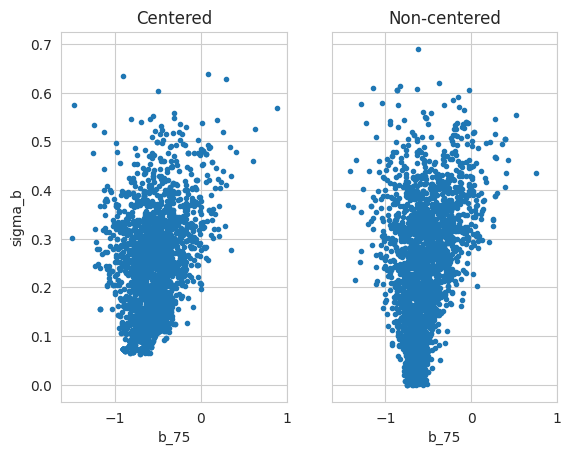

In [ ]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

x = pd.Series(hierarchical_centered_trace.posterior['b'].stack(samples=("chain", "draw"))[74], name='slope b')
y = pd.Series(hierarchical_centered_trace.posterior['sigma_b'].stack(samples=("chain", "draw")), name='slope group variance sigma_b')

axs[0].plot(x, y, '.');
axs[0].set(title='Centered', ylabel='sigma_b', xlabel='b_75')

x = pd.Series(hierarchical_non_centered_trace.posterior['b'].stack(samples=("chain", "draw"))[74], name='slope b')
y = pd.Series(hierarchical_non_centered_trace.posterior['sigma_b'].stack(samples=("chain", "draw")), name='slope group variance sigma_b')

axs[1].plot(x, y, '.');
axs[1].set(title='Non-centered', xlabel='b_75');

Para remarcar aún más la diferencia el autor sugiere generar un gráfico comparativo entre la distribución *a posteriori* marginal de `sigma_b` para ambas versiones del modelo:

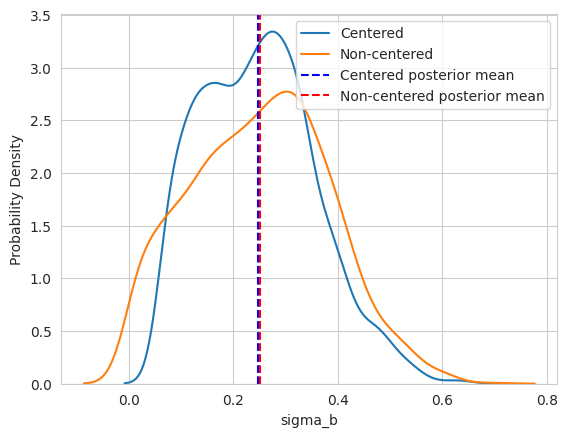

In [ ]:
sns.kdeplot(x=hierarchical_centered_trace.posterior['sigma_b'].stack(samples=("chain", "draw")), label='Centered')
sns.kdeplot(x=hierarchical_non_centered_trace.posterior['sigma_b'].stack(samples=("chain", "draw")), label='Non-centered')

plt.axvline(hierarchical_centered_trace.posterior['sigma_b'].mean(), color='b', linestyle='--', label='Centered posterior mean')
plt.axvline(hierarchical_non_centered_trace.posterior['sigma_b'].mean(), color='red', linestyle='--', label='Non-centered posterior mean')

plt.legend();
plt.xlabel('sigma_b'); plt.ylabel('Probability Density');
plt.show()

Bueno el gráfico no me quedó igual, pero en el de la distribución conjunta se puede ver más. Hay una región grande de pequeños valores de `sigma_b` que durante el muestreo no se pudieron explorar para la versión original del modelo (el modelo no centrado "llega" al 0 mientras que el centrado no!). Esto hizo que nuestras estimaciones previas estuviesen sesgadas hacia valores más altos de `sigma_b`. El autor menciona que el problema con este sesgo es que la media de la distribución *a posteriori* difiere para ambos modelos, **siendo que la del modelo centrado es mayor** (a mi no me pasó :/).

Finalmente el autor menciona lo que este sesgo implica en el análisis que estamos realizando: sobreestimar `sigma_b` significa que tenemos un pensamiento sesgado de que podemos distinguir las pendientes individuales mejor de lo que realmente podemos.

#### ¿Por qué el modelo reparametrizado funcionó mejor?

Para entender porque esta versión del modelo funciona mejor el autor sugiere realizar un gráfico de la distribución *a posteriori* conjunta entre `b_offset` y `b_75`:

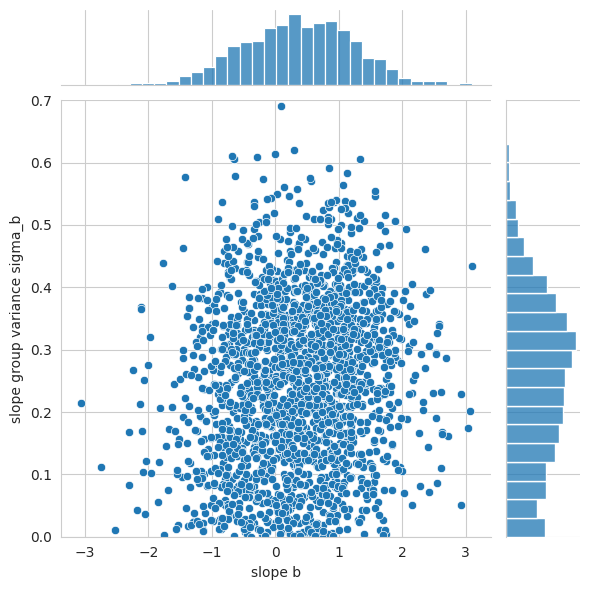

In [ ]:
x = pd.Series(hierarchical_non_centered_trace.posterior['b_offset'].stack(samples=("chain", "draw"))[74], name='slope b')
y = pd.Series(hierarchical_non_centered_trace.posterior['sigma_b'].stack(samples=("chain", "draw")), name='slope group variance sigma_b')

sns.jointplot(x=x, y=y, ylim=(0, .7))

Lo que ocurre es que esta región que estamos observando **es lo que el método de muestreo ve durante la ejecución**. Podemos ver que ya no está más la región angosta del "embudo", este último sigue ahí pero ahora explorarlo **es más fácil**.

#### ¿Por qué los modelos jerárquicos son bayesianos?

Finalmente el autor quiere aprovechar todo este ejemplo sobre modelos jerárquicos para demostrar un punto que aunque no esté relacionado directamente a estos modelos con este caso se puede apreciar bastante bien.

El autor menciona que usualmente cuando hablamos sobre las ventajas de utilizar un enfoque bayesiano en nuestros análisis siempre hablamos sobre el uso de distribuciones *a priori*, tomar en cuenta incertidumbre y la flexibilidad a la hora de programar modelos utilizando un lenguaje de programación probabilística. Sin embargo una ventaja más rara según el autor, y que no se menciona ya que es díficil de comunicar (y con razón), **es la capacidad de poder enfocarse en integrales y esperanzas y no en puntos máximos y modas**.

Entonces aquí entra la pregunta: ¿cúal es el problema con los puntos máximos y las modas?, ¿no es que estos están cerca de la media de la distribución *a posteriori* (su esperanza)?. Aquí el autor remarca que **desafortunadamente este no es el caso cuando trabajamos sobre un modelo complejo (alta dimensionalidad)**, que esta propiedad se ve con los modelos que usualmente se trabajan al aprender estadística bayesiana en donde no hay tanta complejidad.

La relación con los modelos jerárquicos y el por qué se habla de esta situación en esta oportunidad viene dada porque este tipo de modelos cuenta con alta dimensionalidad, y **ocurre que los puntos máximos o modas suelen estar bastante lejos de la media, resultando que no son interesantes de analizar en lo absoluto**.

Luego de todo esto el autor procede a comparar la moda *a posteriori* (MAP) con la media de la distribución para el modelo de regresión lineal jerárquica:

In [9]:
with hierarchical_model_centered:
    mode = pm.find_MAP()

Output()

In [10]:
mode['b']

array([0.08737113, 0.08737117, 0.08737113, 0.08737115, 0.08737113,
       0.08737112, 0.08737115, 0.08737113, 0.08737113, 0.08737114,
       0.08737112, 0.08737112, 0.08737112, 0.08737119, 0.08737113,
       0.08737112, 0.08737114, 0.08737115, 0.08737118, 0.08737112,
       0.08737113, 0.08737113, 0.08737113, 0.08737115, 0.08737115,
       0.08737107, 0.08737114, 0.08737114, 0.08737112, 0.08737112,
       0.08737112, 0.08737112, 0.08737112, 0.08737113, 0.08737114,
       0.08737113, 0.08737113, 0.08737113, 0.08737113, 0.08737113,
       0.08737113, 0.08737112, 0.08737119, 0.08737113, 0.08737117,
       0.08737112, 0.08737113, 0.08737113, 0.08737115, 0.08737112,
       0.08737112, 0.08737112, 0.08737113, 0.08737118, 0.08737114,
       0.08737113, 0.08737113, 0.08737113, 0.08737113, 0.08737112,
       0.08737116, 0.08737113, 0.08737113, 0.08737113, 0.08737112,
       0.08737121, 0.08737116, 0.08737112, 0.08737112, 0.08737115,
       0.08737121, 0.08737112, 0.08737112, 0.08737112, 0.08737

In [22]:
np.exp(np.log(mode['sigma_b']))

np.float64(5.182651999106373e-08)

Aquí podemos ver que las pendientes son todas iguales y la varianza grupal de las mismas es prácticamente 0. La razón para este caso es el embudo que vimos antes (notar que estamos usando la versión centrada). **Al calcular MAP solo nos interesa la región en donde está la densidad máxima, lo cual ocurre en el fondo del embudo**.

Luego el autor se propone a calcular **el valor esperado**, el cual se obtiene integrando la densidad de probabilidad de la distribución junto con su volumen y eso nos lleva a obtener la **masa de probabilidad** que es lo que realmente nos importa. El autor menciona que "por detrás" esto es lo que hacen los métodos de muestreo basados en MCMC que utiliza PyMC.

In [20]:
hierarchical_non_centered_trace.posterior['b'].mean(axis=0).values

array([[-0.6610914 , -0.93497298, -0.48576145, ..., -0.90007266,
        -0.69371931, -0.66475619],
       [-0.40942881, -0.62170993, -0.81996403, ..., -0.80404127,
        -0.774832  , -0.7605053 ],
       [-0.66672624, -0.87578845, -0.3419763 , ..., -0.81759998,
        -0.44921463, -0.62333463],
       ...,
       [-0.72038036, -0.76519092, -0.42624529, ..., -1.39595534,
        -1.0757194 , -1.04952295],
       [-0.72422233, -0.87438177, -0.36005391, ..., -1.25348125,
        -1.0543546 , -1.19660023],
       [-0.52856852, -0.97343635, -0.74742353, ..., -1.46217833,
        -0.73570499, -0.73994808]])

In [21]:
hierarchical_non_centered_trace.posterior['sigma_b'].mean()

<xarray.DataArray 'sigma_b' ()> Size: 8B
array(0.26466286)

Aquí se puede ver claramente la diferencia, además el autor menciona que esto es un claro ejemplo de porque puede ser una mala idea utilizar el MAP para inicializar el muestreo: en ciertos modelos el MAP no está para nada cerca de la región que nos interesa explorar.

El autor termina con una reflexión final basada en las interrogantes: ¿por qué si sabemos las diferencias entre MAP y la esperanza seguimos viendo que se utiliza el primero en varios estudios de Ciencia de Datos y Machine Learning?. **Esto básicamente ocurre porque integrar es más difícil derivar**.